### In this notebook we guide you through an example on how to get started with AESTETIK
1) Data loading and preprocessing
2) Morphology feature extraction
3) Training the model
4) Spot representations and clustering

In [1]:
# Import pyvips first to lock in libvips' libjpeg/libtiff stack
# before scanpy / torch load their own copies (see #14).
import pyvips  # noqa: F401


In [2]:
from pathlib import Path

# Resolve the repository root (parent of the example/ directory).
REPO_ROOT = Path.cwd() if (Path.cwd() / "test_data").is_dir() else Path.cwd().parent
TEST_DATA = REPO_ROOT / "test_data"


### Load required packages

In [3]:
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision import transforms
import squidpy as sq
import scanpy as sc
import torch
import json

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from aestetik.utils.utils_morphology import extract_morphology_embeddings
from aestetik.utils.utils_transcriptomics import preprocess_adata
from aestetik.utils.utils_visualization import visualize
from aestetik import AESTETIK
AESTETIK.version()

'16.06.2025:1'

In [5]:
import logging
# Configure the logging module
logging.basicConfig(level=logging.INFO)  # Set the desired logging level
logging.getLogger("pyvips").setLevel(logging.CRITICAL)

### Load data and preprocess
We start by loading a sample of the `LIBD Human DLPFC` dataset. This sample contains spatially resolved transcriptomics data and a corresponding high-resolution H&E image.

In [6]:
img_path = str(TEST_DATA / "151676.png")
adata_in = str(TEST_DATA / "151676.h5ad")
json_path = str(TEST_DATA / "151676.json")


In [7]:
n_components = 15
spot_diameter_fullres = json.load(open(json_path))["spot_diameter_fullres"]
dot_size = json.load(open(json_path))["dot_size"]

print(f"spot_diameter_fullres: {spot_diameter_fullres}")
print(f"dot_size: {dot_size}")

spot_diameter_fullres: 145
dot_size: 5


In [8]:
adata = sc.read_h5ad(adata_in)
#adata = adata[adata.obs.sample(100).index,:] # to speed up, we only select 100 spots.
adata = preprocess_adata(adata)

print(adata)

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


AnnData object with n_obs × n_vars = 3431 × 6354
    obs: 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'genename', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'log1p', 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'


1) `x_array` and `y_array` contain the spatial coordinates of the spots on the array
2) `x_pixel` and `y_pixel`contain the spatial coordinates of the spots in the image
3) `ground_truth` contains spot annotations

In [9]:
adata.obs.head()

,x_array,y_array,x_pixel,y_pixel,ground_truth
AAACAAGTATCTCCCA-1,50,102,1083.250,1206.250,Layer_3
AAACAATCTACTAGCA-1,3,43,375.750,703.750,Layer_1
AAACACCAATAACTGC-1,59,19,1212.750,491.000,WM
AAACAGAGCGACTCCT-1,14,94,543.750,1141.375,Layer_3
AAACAGGGTCTATATT-1,47,13,1032.625,440.625,Layer_6


### Extract morphology features

In this example, we use Inception V3 to extract morphology spot features. For this, we use the last layer with dimension 2048. After that, we apply PCA to reduce the feature dimensions from 2048 to 15.

In [10]:
weights = Inception_V3_Weights.DEFAULT
morphology_model = inception_v3(weights=weights)
morphology_model.fc = torch.nn.Identity()

morphology_model.eval()    
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
feature_dim = 2048

preprocess = transforms.Compose([
                transforms.ToTensor(),
                weights.transforms(antialias=True),
            ])

features_inception_v3 = extract_morphology_embeddings(img_path, 
                                             morphology_model,
                                             x_pixel=adata.obs.y_pixel, 
                                             y_pixel=adata.obs.x_pixel, 
                                             spot_diameter=spot_diameter_fullres,
                                             device=device,
                                             n_components=n_components,
                                             feature_dim=feature_dim,
                                             preprocess=preprocess,
                                             apply_pca=True)

  0%|          | 0/3431 [00:00<?, ?it/s]

  0%|          | 1/3431 [00:00<26:06,  2.19it/s]

  0%|          | 5/3431 [00:00<05:19, 10.72it/s]

  0%|          | 9/3431 [00:00<03:22, 16.86it/s]

  0%|          | 13/3431 [00:00<02:41, 21.14it/s]

...

100%|█████████▉| 3417/3431 [01:45<00:00, 33.60it/s]

100%|█████████▉| 3421/3431 [01:45<00:00, 32.70it/s]

100%|█████████▉| 3425/3431 [01:45<00:00, 32.51it/s]

100%|█████████▉| 3429/3431 [01:45<00:00, 32.13it/s]

100%|██████████| 3431/3431 [01:45<00:00, 32.52it/s]

We store the transcriptomics data in `X_pca_transcriptomics` and morphology data in `X_pca_morphology`.

In [11]:
# we set the transcriptomics modality
adata.obsm["X_pca_transcriptomics"] = adata.obsm["X_pca"][:,0:n_components]

print(f"{adata.obsm['X_pca_transcriptomics'].shape[0]} spots x {adata.obsm['X_pca_transcriptomics'].shape[1]} transcriptomics PCA components")

3431 spots x 15 transcriptomics PCA components


In [12]:
# we set the morphology modality
adata.obsm["X_pca_morphology"] = features_inception_v3[:,0:n_components]

print(f"{adata.obsm['X_pca_morphology'].shape[0]} spots x {adata.obsm['X_pca_morphology'].shape[1]} morphology PCA components")

3431 spots x 15 morphology PCA components


### Model training

In our example, we set the morphology weight to 0 (no morphology contribution) and we refine the clusters in spatial space.

In [13]:
parameters =    {'morphology_weight': 0,
                 'refine_cluster': True,
                 'window_size': 7
                }
parameters

{'morphology_weight': 0, 'refine_cluster': True, 'window_size': 7}

In [14]:
model = AESTETIK(nCluster=adata.obs.ground_truth.unique().size,
                 **parameters)

[rank: 0] Seed set to 2023


In [15]:
model.fit(X=adata)

INFO:aestetik.AESTETIK:Initializing datamodule ...


INFO:aestetik.AESTETIK:Build AESTETIKModel ...


INFO:aestetik.modules.aestetik_module:Validate parameters in LitAESTETIKModel ...


INFO:aestetik.AESTETIK:Fit AESTETIKModel ...


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/home/knonchev/miniconda3/envs/aestetik-test ...
GPU available: True (cuda), used: True


...

┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ AE   │  110 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 110 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 110 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 60                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


`Trainer.fit` stopped: `max_epochs=100` reached.


### Compute embeddings and clustering

In [16]:
model.predict(X=adata, cluster=True)

INFO:aestetik.utils.utils_data:Computing transcriptomics grid...


INFO:aestetik.utils.utils_grid:No batch column specified or found in adata.obs. We treat all data as coming from a single tissue slice.


INFO:aestetik.utils.utils_data:Computing morphology grid...


INFO:aestetik.utils.utils_grid:No batch column specified or found in adata.obs. We treat all data as coming from a single tissue slice.


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/home/knonchev/miniconda3/envs/aestetik-test ...
INFO:aestetik.utils.utils_data:Clustering raw input with bgm...


...

INFO:aestetik.utils.utils_data:Computing morphology grid...


INFO:aestetik.utils.utils_grid:No batch column specified or found in adata.obs. We treat all data as coming from a single tissue slice.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


In [17]:
adata

AnnData object with n_obs × n_vars = 3431 × 6354
    obs: 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth', 'X_pca_transcriptomics_cluster', 'X_pca_transcriptomics_cluster_proba', 'X_pca_morphology_cluster', 'X_pca_morphology_cluster_proba', 'AESTETIK_cluster', 'AESTETIK_cluster_proba'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'genename', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'log1p', 'pca'
    obsm: 'spatial', 'X_pca', 'X_pca_transcriptomics', 'X_pca_morphology', 'X_st_grid', 'AESTETIK'
    varm: 'PCs'

Finally, spot representations can be found in `adata.obsm["AESTETIK"]` and clusters in `adata.obs["AESTETIK_cluster"]`. We can visualize the clusters:

... storing 'X_pca_transcriptomics_cluster' as categorical


... storing 'X_pca_morphology_cluster' as categorical


... storing 'AESTETIK_cluster' as categorical


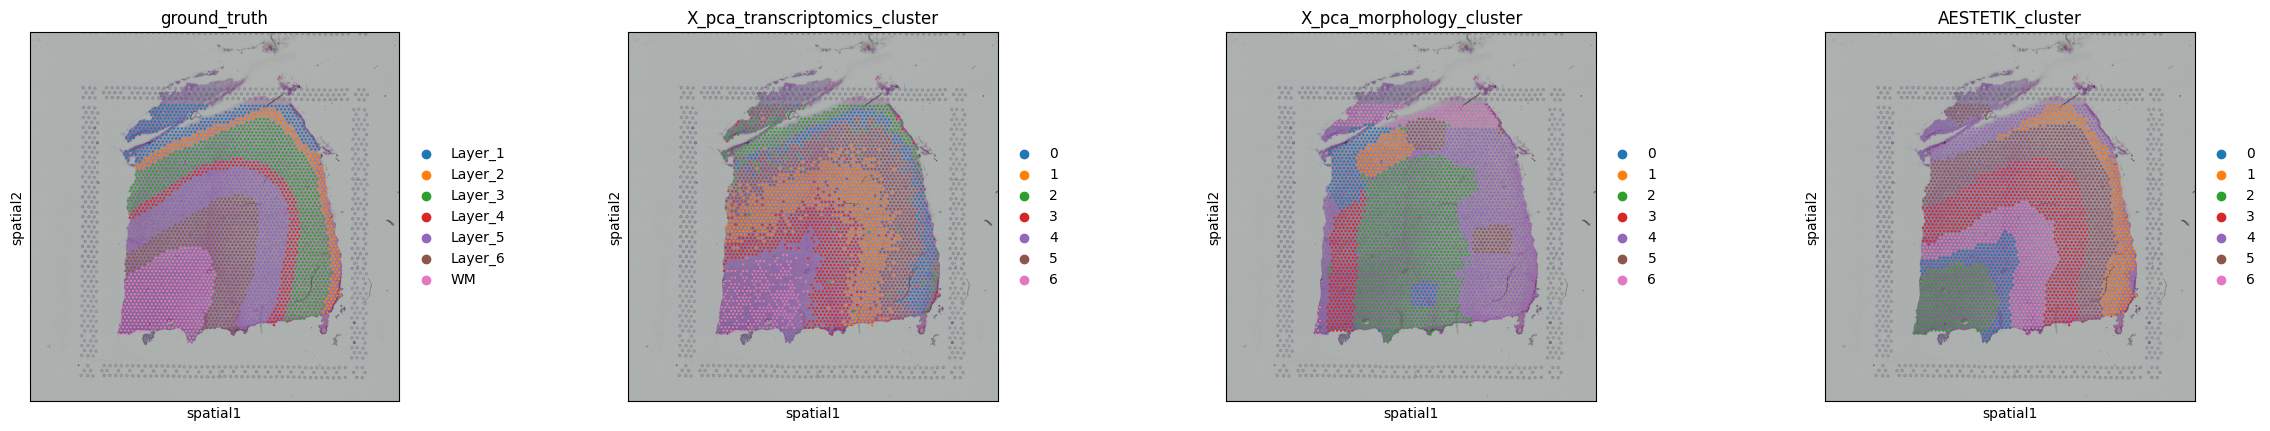

In [18]:
sq.pl.spatial_scatter(adata, color=["ground_truth", 
                                    "X_pca_transcriptomics_cluster",
                                    "X_pca_morphology_cluster",
                                    "AESTETIK_cluster"], size=dot_size)

To analyze the model's performance during training, we can also plot the training loss: 

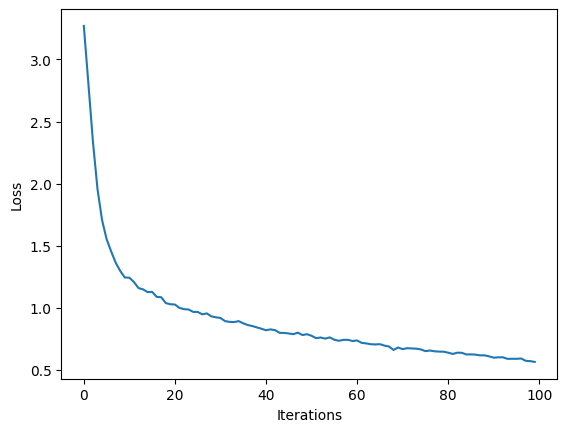

In [19]:
visualize(model=model,
          plot_loss=True)